In [34]:
import rustworkx as rx
import matplotlib.pyplot as plt
import numpy as np
from tn4qa.quantum_algorithms.hamiltonian_simulation.qdrift import QDriftSimulation
from nbed.ham_builder import HamiltonianBuilder
import pyscf
import qiskit.qasm2

from ferrmion.hamiltonians import molecular_hamiltonian
from ferrmion.utils import fermionic_to_sparse_majorana
from ferrmion.encode import JordanWigner, ParityEncoding, BravyiKitaev, JKMN
from ferrmion.optimize.bonsai import bonsai_algorithm
from ferrmion.optimize.topphatt import topphatt

In [2]:
garnet_edges = [
    (1, 0),
    (1, 4),
    (3, 0),
    (3, 2),
    (3, 4),
    (3, 8),
    (5, 4),
    (5, 6),
    (5, 10),
    (7, 2),
    (7, 8),
    (7, 12),
    (9, 4),
    (9, 8),
    (9, 10),
    (9, 14),
    (11, 6),
    (11, 10),
    (11, 16),
    (13, 8),
    (13, 12),
    (13, 14),
    (13, 17),
    (15, 10),
    (15, 14),
    (15, 16),
    (15, 19),
    (18, 14),
    (18, 17),
    (18, 19)
]

In [3]:
def make_ham_real(hamiltonian: dict[str, complex]) -> dict[str, float]:
    real_ham = {}
    for item in hamiltonian:
        real_ham[item] = np.real(hamiltonian[item])
    return real_ham

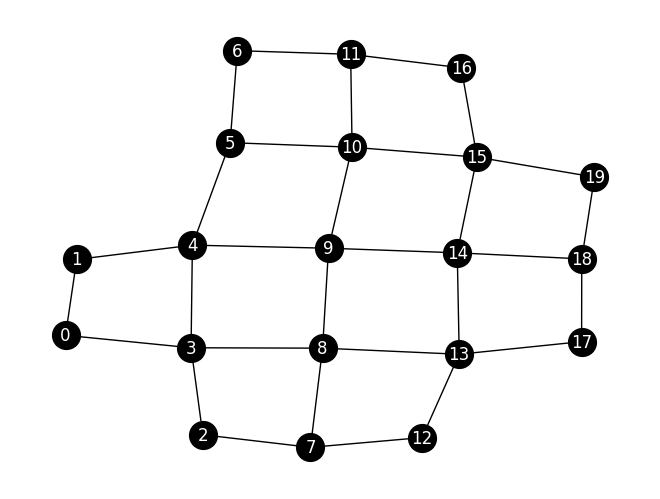

In [4]:
#rustworkx graph from edges (the actual input for bonsai)

garnet_graph_rx = rx.PyGraph()
num_qubits = max(max(pair) for pair in garnet_edges) + 1
garnet_graph_rx.add_nodes_from(range(num_qubits))
garnet_graph_rx.add_edges_from_no_data(garnet_edges)

rx.visualization.mpl_draw(
    graph = garnet_graph_rx, 
    with_labels = True,
    node_color = 'black',
    node_size = 400,
    font_color = 'white',
    pos = rx.spring_layout(garnet_graph_rx, seed=5)
)

In [5]:
mol_obj = pyscf.M(
    atom = 'mols/H2O.xyz',
    basis = 'sto-3g'
)

print('qubits =', mol_obj.nao*2)

qubits = 14


In [6]:
rhf_obj = pyscf.scf.RHF(mol_obj).run()

converged SCF energy = -74.9659011922597


In [7]:
e_nuc, one_e_coeffs, two_e_coeffs = HamiltonianBuilder(
    scf_method=rhf_obj,
    constant_e_shift=mol_obj.energy_nuc()
).build()

In [8]:
def get_hams(encoding_tree, one_e_coeffs, two_e_coeffs, e_nuc):
    ham = molecular_hamiltonian(
        encoding = encoding_tree, 
        one_e_coeffs = one_e_coeffs, 
        two_e_coeffs = two_e_coeffs, 
        constant_energy = e_nuc
    )
    tophatt_tree = topphatt(
        majorana_ham = fermionic_to_sparse_majorana(((one_e_coeffs,"+-"), (two_e_coeffs, "++--"))),
        tree = encoding_tree
    )
    tophatt_ham = molecular_hamiltonian(
        encoding = tophatt_tree, 
        one_e_coeffs = one_e_coeffs, 
        two_e_coeffs = two_e_coeffs, 
        constant_energy = e_nuc
    )
    ham = make_ham_real(ham)
    tophatt_ham = make_ham_real(tophatt_ham)
    return (ham, tophatt_ham)

In [9]:
bonsai_garnet_truncated = bonsai_algorithm(
    graph = garnet_graph_rx,
    homogenous = False,
    max_nodes = 14
)

In [10]:
bonsai_hams = get_hams(
    encoding_tree = bonsai_garnet_truncated,
    one_e_coeffs = one_e_coeffs,
    two_e_coeffs = two_e_coeffs,
    e_nuc = e_nuc
)

In [11]:
jw_hams = get_hams(
    encoding_tree = JordanWigner(one_e_coeffs.shape[0]),
    one_e_coeffs = one_e_coeffs,
    two_e_coeffs = two_e_coeffs,
    e_nuc = e_nuc
)

In [12]:
bk_hams = get_hams(
    encoding_tree = BravyiKitaev(one_e_coeffs.shape[0]),
    one_e_coeffs = one_e_coeffs,
    two_e_coeffs = two_e_coeffs,
    e_nuc = e_nuc
)

In [13]:
parity_hams = get_hams(
    encoding_tree = ParityEncoding(one_e_coeffs.shape[0]),
    one_e_coeffs = one_e_coeffs,
    two_e_coeffs = two_e_coeffs,
    e_nuc = e_nuc
)

In [14]:
jkmn_hams = get_hams(
    encoding_tree = JKMN(one_e_coeffs.shape[0]),
    one_e_coeffs = one_e_coeffs,
    two_e_coeffs = two_e_coeffs,
    e_nuc = e_nuc
)

In [15]:
def run_qdrift(hams, duration):
    qdrift = QDriftSimulation(
        hamiltonian = hams[0],
        duration = duration
    )
    naive_depth = qdrift.circuit.depth()

    qdrift = QDriftSimulation(
        hamiltonian = hams[1],
        duration = duration
    )
    tophatt_depth = qdrift.circuit.depth()

    return (naive_depth, tophatt_depth)

In [18]:
results = {
    "bonsai":   {"hams": bonsai_hams,  "naive": [], "topphatt": []},
    "JW":       {"hams": jw_hams,      "naive": [], "topphatt": []},
    "BK":       {"hams": bk_hams,      "naive": [], "topphatt": []},
    "parity":   {"hams": parity_hams,  "naive": [], "topphatt": []},
    "JKMN":     {"hams": jkmn_hams,    "naive": [], "topphatt": []},
}

In [20]:
dur = 0.001
repeats = 2000

for _ in range(repeats):
    for encoding, data in results.items():
        naive_depth, tophatt_depth = run_qdrift(data["hams"], dur)
        data["naive"].append(naive_depth)
        data["topphatt"].append(tophatt_depth)

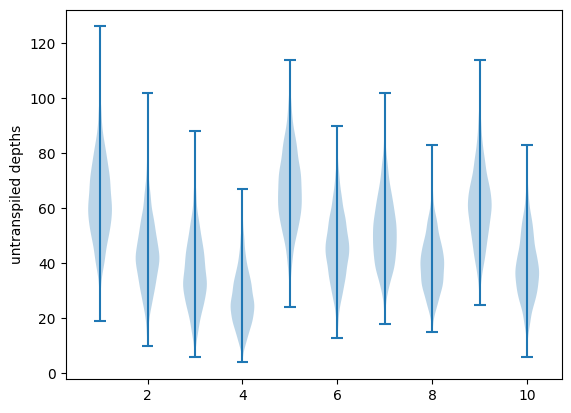

In [21]:
plt.violinplot([
    results["bonsai"]["naive"],
    results["bonsai"]["topphatt"],
    results["JW"]["naive"],
    results["JW"]["topphatt"],
    results["BK"]["naive"],
    results["BK"]["topphatt"],
    results["parity"]["naive"],
    results["parity"]["topphatt"],
    results["JKMN"]["naive"],
    results["JKMN"]["topphatt"],
])

plt.ylabel('untranspiled depths')

plt.show()

In [22]:
for encoding, data in results.items():
    print(encoding)

bonsai
JW
BK
parity
JKMN


In [23]:
order = ["JW", "JKMN", "parity", "bonsai", "BK"]


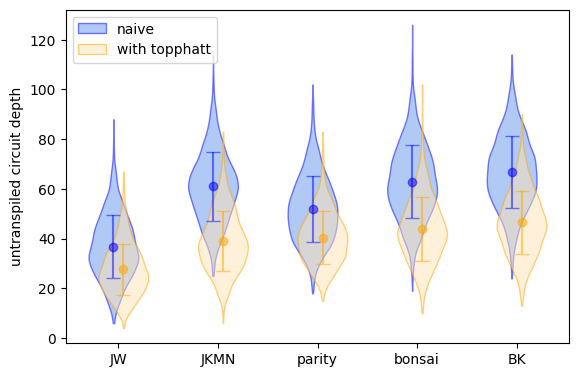

In [45]:
spacing = 0.05

naive_data   = [results[name]["naive"] for name in order]
tophatt_data = [results[name]["topphatt"]    for name in order]

positions_naive   = [i + 1 - spacing for i in range(len(order))]
positions_tophatt = [i + 1 + spacing for i in range(len(order))]

plt.figure(figsize=(468/72, (468*(2/3))/72))
plt.tight_layout()

naive_violin = plt.violinplot(
    dataset=naive_data,
    positions=positions_naive,
)
tophatt_violin = plt.violinplot(
    dataset=tophatt_data,
    positions=positions_tophatt,
)

alpha = 0.5
naive_edge = 'blue'
naive_fill = 'cornflowerblue'
tophatt_edge = 'orange'
tophatt_fill = 'moccasin'

for i, body in enumerate(naive_violin['bodies']):
    body.set_facecolor(naive_fill)
    body.set_edgecolor(naive_edge)
    body.set_alpha(alpha)

naive_violin['bodies'][0].set_label("naive")

for i, body in enumerate(tophatt_violin['bodies']):
    body.set_facecolor(tophatt_fill)
    body.set_edgecolor(tophatt_edge)
    body.set_alpha(alpha)

tophatt_violin['bodies'][0].set_label("with topphatt")


for key in ["cbars", "cmaxes", "cmins"]:
    naive_violin[key].set_color("none")
    tophatt_violin[key].set_color("none")

for i, name in enumerate(order):
    x_naive = positions_naive[i]
    x_topphatt = positions_tophatt[i]

    y_naive = np.mean(results[name]["naive"])
    e_naive = np.std(results[name]["naive"])

    y_topphatt = np.mean(results[name]["topphatt"])
    e_topphatt = np.std(results[name]["topphatt"])

    plt.errorbar(x=x_naive, y=y_naive,
                 yerr=e_naive, fmt='o', color=naive_edge,
                 capsize=5, alpha=alpha)

    plt.errorbar(x=x_topphatt, y=y_topphatt,
                 yerr=e_topphatt, fmt='o', color=tophatt_edge,
                 capsize=5, alpha=alpha)

plt.legend(loc="upper left")
plt.xticks([i + 1 for i in range(len(order))], order)
plt.ylabel("untranspiled circuit depth")

plt.savefig("untranspiled_qdrift.pdf")

plt.show()

In [41]:
for name in order:
    print(np.mean(results[name]["topphatt"]))

27.6355
39.001
40.354
43.7355
46.478


In [40]:
for encoding in order:
    data = results[encoding]
    hams = data["hams"]

    for variant, ham in zip(["naive", "topphatt"], hams):
        
        target_depth = int(np.mean(data[variant]))
        filename = f"{encoding}_{variant}_mean.qasm"

        while True:
            qdrift = QDriftSimulation(hamiltonian=ham, duration=dur)

            if qdrift.circuit.depth() == target_depth:
                qiskit.qasm2.dump(qdrift.circuit, filename)
                print(f"done {encoding} {variant}")
                break

done JW naive
done JW topphatt
done JKMN naive
done JKMN topphatt
done parity naive
done parity topphatt
done bonsai naive
done bonsai topphatt
done BK naive
done BK topphatt
